### Imports

In [1]:
from pyspark.sql import (SparkSession, functions as F)
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    LongType, TimestampType
)
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
import openmeteo_requests
import pandas as pd
import geopandas as gpd
import numpy as np
import requests_cache
from retry_requests import retry
import os
import matplotlib.pyplot as plt

Start Spark Session

In [2]:
spark = (
    SparkSession.builder
    .appName("MAST30034_Project1")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "localhost")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 09:40:39 WARN Utils: Your hostname, Harrys-MacBook-Air-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.8 instead (on interface en0)
26/08/31 09:40:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/31 09:40:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Reading in data

TLC data:

In [3]:
tlc_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count", LongType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", LongType(), True),                 # new
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
])

# Jan–Jun 2025, six files, one schema
months = [f"2025-{m:02d}" for m in range(1, 7)]
tlc_paths = [f"data/tlc_data/{m}.parquet" for m in months]

tlc_sdf = spark.read.schema(tlc_schema).parquet(*tlc_paths)
tlc_sdf.printSchema()
raw_row_count = tlc_sdf.count()   # replaces the hardcoded 3475226 used later
print(f"Shape: ({raw_row_count}, {len(tlc_sdf.columns)})")
tlc_sdf.show(5)

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)

Shape: (24083384, 17)
+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+--------

Open Meteo data:   
Following code was adapted from https://open-meteo.com/en/docs/historical-weather-api?start_date=2025-01-01&end_date=2025-07-01&hourly=temperature_2m,wind_speed_10m,rain,snowfall,snow_depth,precipitation,apparent_temperature,weather_code,cloud_cover,wind_direction_10m&daily=sunrise,sunset,daylight_duration

In [4]:
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"

locations = {
    "central_park": (40.7829, -73.9654),
    "jfk": (40.6413, -73.7781),
    "laguardia": (40.7769, -73.8740),
}

hourly_vars = [
    "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "snowfall", "snow_depth", "wind_speed_10m",
    "wind_direction_10m", "weather_code", "cloud_cover",
]

all_dfs = []
for station_name, (lat, lon) in locations.items():
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2024-12-31",   # 1-day buffer before Jan 1, 2025 local midnight
        "end_date": "2025-07-01",     # 1-day buffer after Jun 30, 2025 local midnight
        "hourly": hourly_vars,
        "timezone": "America/New_York",  # DST-aware: EST through early Mar, EDT after
    }
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()

    hourly_data = {
        "date": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )
    }
    for i, var in enumerate(hourly_vars):
        hourly_data[var] = hourly.Variables(i).ValuesAsNumpy()

    df = pd.DataFrame(data=hourly_data)
    df["station"] = station_name
    df["latitude"] = lat
    df["longitude"] = lon
    all_dfs.append(df)

weather_df = pd.concat(all_dfs, ignore_index=True)
os.makedirs("data/weather_data", exist_ok=True)
weather_sdf = spark.read.csv("data/weather_data/nyc_weather_openmeteo_2025-01_to_2025-06.csv",  header=True, inferSchema=True)
weather_df.to_csv("data/weather_data/nyc_weather_openmeteo_2025-01_to_2025-06.csv", index=False)
print(weather_df.shape)
weather_df["date"].min(), weather_df["date"].max()

(13176, 14)


(Timestamp('2024-12-31 04:00:00+0000', tz='UTC'),
 Timestamp('2025-07-02 03:00:00+0000', tz='UTC'))

Taxi zone data:

In [5]:
zones = spark.read.csv("data/taxi_zones/taxi+_zone_lookup.csv", header=True, inferSchema=True)
zones.printSchema()
zones.show(5)

root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


Load the taxi zone shapefile, which has the zone boundaries (geometry) needed for mapping later.

In [6]:
zones_geo = gpd.read_file("data/taxi_zones/taxi_zones.shp")  


Build a summary table showing the row count and column count for each raw dataset before any cleaning.

In [7]:
raw_datasets = {
    "TLC Yellow Taxi Trip Record Data": tlc_sdf,
    "NYC Taxi Zone Lookup": zones,
    "Open-Meteo Historical Weather Data": weather_sdf,
}

before_rows = []
for name, df in raw_datasets.items():
    before_rows.append((name, df.count(), len(df.columns)))

before_df = spark.createDataFrame(before_rows, ["Datasets", "Instances", "No. features"])
before_df.show(truncate=False)

+----------------------------------+---------+------------+
|Datasets                          |Instances|No. features|
+----------------------------------+---------+------------+
|TLC Yellow Taxi Trip Record Data  |24083384 |17          |
|NYC Taxi Zone Lookup              |265      |4           |
|Open-Meteo Historical Weather Data|13176    |14          |
+----------------------------------+---------+------------+



# Data Preprocessing / Cleaning

### First we examine the taxi zone data

In [8]:
zones.printSchema()
print(f"Raw zones shape: ({zones.count()}, {len(zones.columns)})")

# check duplicate and Null counts
zones.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in zones.columns]).show()
dupe_ids = zones.groupBy("LocationID").count().filter(F.col("count") > 1)
print(f"Duplicate LocationID rows: {dupe_ids.count()}")

# "Unknown"/"N/A" zones (these are real TLC placeholder values for unrecognized locations)
zones.filter(
    (F.col("Zone") == "Unknown") | (F.col("Zone") == "N/A") | F.col("Zone").isNull()
).show()

# Borough value distribution 
zones.groupBy("Borough").count().orderBy(F.desc("count")).show()

root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

Raw zones shape: (265, 4)
+----------+-------+----+------------+
|LocationID|Borough|Zone|service_zone|
+----------+-------+----+------------+
|         0|      0|   0|           0|
+----------+-------+----+------------+

Duplicate LocationID rows: 0
+----------+-------+----+------------+
|LocationID|Borough|Zone|service_zone|
+----------+-------+----+------------+
+----------+-------+----+------------+

+-------------+-----+
|      Borough|count|
+-------------+-----+
|    Manhattan|   69|
|       Queens|   69|
|     Brooklyn|   61|
|        Bronx|   43|
|Staten Island|   20|
|      Unknown|    2|
|          EWR|    1|
+-------------+-----+



### Next, the weather data

In [9]:
raw_weather_count = weather_sdf.count()
print(f"Raw weather rows: {raw_weather_count}")
weather_sdf.printSchema()
weather_sdf.show(5)

# Null counts per column 
weather_sdf.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in weather_sdf.columns]).show(vertical=True)

#  Min/max for numeric columns,  check for implausible negative values 
weather_numeric_cols = [f.name for f in weather_sdf.schema.fields if f.dataType.typeName() in ("double", "long", "integer")]
weather_sdf.select(
    [F.min(c).alias(f"{c}_min") for c in weather_numeric_cols] +
    [F.max(c).alias(f"{c}_max") for c in weather_numeric_cols]
).show(vertical=True)

#  Check for missing hours per station 
weather_sdf.groupBy("station").count().show()

# Check for duplicate (station, date) pairs
dupes = weather_sdf.groupBy("station", "date").count().filter(F.col("count") > 1)
print(f"Duplicate station-hour rows: {dupes.count()}")

#  Remove any negative values in physically non-negative columns 
# (precipitation, snowfall, snow_depth, wind_speed, cloud_cover, humidity cannot be negative)
non_negative_cols = ["relative_humidity_2m", "precipitation", "snowfall", "snow_depth", "wind_speed_10m", "cloud_cover"]
weather_negative_condition = None
for c in non_negative_cols:
    cond = (F.col(c) >= 0) | F.col(c).isNull()
    weather_negative_condition = cond if weather_negative_condition is None else (weather_negative_condition & cond)
weather_sdf = weather_sdf.filter(weather_negative_condition)

clean_weather_count = weather_sdf.count()
print(f"Clean weather rows: {clean_weather_count}")
print(f"Removed: {raw_weather_count - clean_weather_count}")

Raw weather rows: 13176
root
 |-- date: timestamp (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- relative_humidity_2m: double (nullable = true)
 |-- apparent_temperature: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- snowfall: double (nullable = true)
 |-- snow_depth: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- wind_direction_10m: double (nullable = true)
 |-- weather_code: double (nullable = true)
 |-- cloud_cover: double (nullable = true)
 |-- station: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)

+-------------------+--------------+--------------------+--------------------+-------------+--------+----------+--------------+------------------+------------+-----------+------------+--------+---------+
|               date|temperature_2m|relative_humidity_2m|apparent_temperature|precipitation|snowfall|snow_depth|wind_speed_10m|wind_direction_10m|w

### Now, examine tlc dataset   
(merge with zone data first)

In [10]:
tlc_joined = (
    tlc_sdf
    .join(
        zones.select(
            F.col("LocationID").alias("PULocationID"),
            F.col("Zone").alias("PU_Zone"),
            F.col("Borough").alias("PU_Borough"),
        ),
        on="PULocationID",
        how="left"
    )
    .join(
        zones.select(
            F.col("LocationID").alias("DOLocationID"),
            F.col("Zone").alias("DO_Zone"),
            F.col("Borough").alias("DO_Borough"),
        ),
        on="DOLocationID",
        how="left"
    )
)

print(f"Before join: {raw_row_count} rows")
print(f"After join: {tlc_joined.count()} rows")

tlc_joined.select("PULocationID", "PU_Zone", "PU_Borough", "DOLocationID", "DO_Zone", "DO_Borough").show(5)

Before join: 24083384 rows
After join: 24083384 rows
+------------+--------------------+----------+------------+--------------------+----------+
|PULocationID|             PU_Zone|PU_Borough|DOLocationID|             DO_Zone|DO_Borough|
+------------+--------------------+----------+------------+--------------------+----------+
|         229|Sutton Place/Turt...| Manhattan|         237|Upper East Side S...| Manhattan|
|         236|Upper East Side N...| Manhattan|         237|Upper East Side S...| Manhattan|
|         141|     Lenox Hill West| Manhattan|         141|     Lenox Hill West| Manhattan|
|         244|Washington Height...| Manhattan|         244|Washington Height...| Manhattan|
|         244|Washington Height...| Manhattan|         116|    Hamilton Heights| Manhattan|
+------------+--------------------+----------+------------+--------------------+----------+
only showing top 5 rows


Examining what the tlc parquet actually looks like, how much "bad' data is present?

In [11]:

# Structure
tlc_joined.printSchema()
print(f"Shape: ({tlc_joined.count()}, {len(tlc_joined.columns)})")   # fixed: was tlc_sdf

#check first 5 rows 
tlc_joined.show(5, vertical=True)

# Min/max for every numeric column
numeric_cols = [f.name for f in tlc_joined.schema.fields if f.dataType.typeName() in ("double", "long", "integer")]

tlc_joined.select([
    F.min(c).alias(f"{c}_min") for c in numeric_cols
] + [
    F.max(c).alias(f"{c}_max") for c in numeric_cols
]).show(vertical=True)

# Summary stats (count/mean/stddev/min/max) on key numeric columns
tlc_joined.select("trip_distance", "fare_amount", "tip_amount", "total_amount", "passenger_count").describe().show()

# Null counts per column 
print("--- Null counts ---")
tlc_joined.select([   F.sum(F.col(c).isNull().cast("int")).alias(c) for c in tlc_joined.columns   # fixed: was tlc_sdf.columns
]).show(vertical=True)

# Date range actually present — confirms whether stray rows from adjacent
# months leaked into the file
tlc_joined.select(
    F.min("tpep_pickup_datetime").alias("earliest_pickup"),
    F.max("tpep_pickup_datetime").alias("latest_pickup")
).show()

root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- DO_Zone: string (nullable = true)
 |-- DO_Borough: string (nullable = true)

Shape: (24083384, 21)
-RECORD 0-------------------------------------
 DOL

26/08/31 09:40:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0------------------------------
 DOLocationID_min          | 1         
 PULocationID_min          | 1         
 VendorID_min              | 1         
 passenger_count_min       | 0         
 trip_distance_min         | 0.0       
 RatecodeID_min            | 1         
 payment_type_min          | 0         
 fare_amount_min           | -1807.6   
 extra_min                 | -17.39    
 mta_tax_min               | -21.74    
 tip_amount_min            | -220.0    
 tolls_amount_min          | -148.17   
 improvement_surcharge_min | -1.0      
 congestion_surcharge_min  | -2.5      
 total_amount_min          | -1832.85  
 DOLocationID_max          | 265       
 PULocationID_max          | 265       
 VendorID_max              | 7         
 passenger_count_max       | 9         
 trip_distance_max         | 386088.43 
 RatecodeID_max            | 99        
 payment_type_max          | 5         
 fare_amount_max           | 863372.12 
 extra_max                 | 133.6     


+-------+------------------+------------------+------------------+------------------+------------------+
|summary|     trip_distance|       fare_amount|        tip_amount|      total_amount|   passenger_count|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|          24083384|          24083384|          24083384|          24083384|          18664783|
|   mean|6.8280110955333395|17.885350687010387|2.8550079291165202| 26.36060361783981|1.2948589329969709|
| stddev| 630.5676446847369|191.09362744537822|3.8914949090133875|191.55895493878384|0.7363831857050768|
|    min|               0.0|           -1807.6|            -220.0|          -1832.85|                 0|
|    max|         386088.43|         863372.12|            960.94|         863380.37|                 9|
+-------+------------------+------------------+------------------+------------------+------------------+

--- Null counts ---


-RECORD 0------------------------
 DOLocationID          | 0       
 PULocationID          | 0       
 VendorID              | 0       
 tpep_pickup_datetime  | 0       
 tpep_dropoff_datetime | 0       
 passenger_count       | 5418601 
 trip_distance         | 0       
 RatecodeID            | 5418601 
 payment_type          | 0       
 fare_amount           | 0       
 extra                 | 0       
 mta_tax               | 0       
 tip_amount            | 0       
 tolls_amount          | 0       
 improvement_surcharge | 0       
 congestion_surcharge  | 5418601 
 total_amount          | 0       
 PU_Zone               | 0       
 PU_Borough            | 0       
 DO_Zone               | 0       
 DO_Borough            | 0       

+-------------------+-------------------+
|    earliest_pickup|      latest_pickup|
+-------------------+-------------------+
|2007-12-05 18:45:00|2025-06-30 23:59:59|
+-------------------+-------------------+



##### Cleaning
Drop all rows with negative values, choose 100 miles as cut off for journey distance, anything above that can be considered an outlier for the sake of this project, choose $500 as cut off for fare, 3 hours for trip length, and remove trips have "implausibly" high fares for short journeys

In [12]:
before = tlc_joined.count()

# Create trip duration column 
tlc_joined = tlc_joined.withColumn(
    "trip_duration_sec",
    F.col("tpep_dropoff_datetime").cast("long") - F.col("tpep_pickup_datetime").cast("long")
)

# --- Remove rows with a negative value in any numeric column (applies to everyone) ---
numeric_cols = [f.name for f in tlc_joined.schema.fields if f.dataType.typeName() in ("double", "long", "integer")]
negative_condition = None
for c in numeric_cols:
    cond = (F.col(c) >= 0) | F.col(c).isNull()
    negative_condition = cond if negative_condition is None else (negative_condition & cond)
tlc_joined = tlc_joined.filter(negative_condition)

# --- Remove trips over 100 miles, but only for standard metered trips (RatecodeID == 1) ---
# flat-rate/negotiated/unknown rate codes aren't distance-based, so don't apply this cap to them
distance_ok = (F.col("RatecodeID") != 1) | F.col("RatecodeID").isNull() | (F.col("trip_distance") <= 100)
tlc_joined = tlc_joined.filter(distance_ok)

# Universal cap — applies to every fare regardless of rate code,
tlc_joined = tlc_joined.filter(F.col("trip_distance") <= 250)

# --- Remove implausible near-zero-distance/high-fare trips
implausible = (
    (F.col("trip_distance") < 0.5) &
    (F.col("fare_amount") > 50)
)
tlc_joined = tlc_joined.filter(~implausible)

# --- Remove fares over $500) ---
tlc_joined = tlc_joined.filter(F.col("fare_amount") <= 500)

# --- Remove trips with non-positive duration (dropoff at/before pickup) ---
tlc_joined = tlc_joined.filter(F.col("trip_duration_sec") > 0)

# --- Remove trips exceeding 3 hours 
tlc_joined = tlc_joined.filter(F.col("trip_duration_sec") <= 3*3600)

# --- Remove out-of-month trips (stray Dec 2024 / July 2025 rows) ---
tlc_joined = tlc_joined.filter(
    (F.col("tpep_pickup_datetime") >= "2025-01-01") &
    (F.col("tpep_pickup_datetime") < "2025-07-01")
)

after = tlc_joined.count()
print(f"Before: {before}")
print(f"After: {after}")
print(f"Removed: {before - after} ({(before - after)/before:.2%})")



# --- Recompute min/max for every numeric column ---
tlc_joined.select([
    F.min(c).alias(f"{c}_min") for c in numeric_cols
] + [
    F.max(c).alias(f"{c}_max") for c in numeric_cols
]).show(vertical=True)

# --- Recompute mean/stddev on key columns ---
tlc_joined.select("trip_distance", "fare_amount", "tip_amount", "total_amount", "passenger_count").describe().show()

Before: 24083384
After: 22462577
Removed: 1620807 (6.73%)


-RECORD 0----------------------------
 DOLocationID_min          | 1       
 PULocationID_min          | 1       
 VendorID_min              | 1       
 passenger_count_min       | 0       
 trip_distance_min         | 0.0     
 RatecodeID_min            | 1       
 payment_type_min          | 0       
 fare_amount_min           | 0.0     
 extra_min                 | 0.0     
 mta_tax_min               | 0.0     
 tip_amount_min            | 0.0     
 tolls_amount_min          | 0.0     
 improvement_surcharge_min | 0.0     
 congestion_surcharge_min  | 0.0     
 total_amount_min          | 0.0     
 trip_duration_sec_min     | 1       
 DOLocationID_max          | 265     
 PULocationID_max          | 265     
 VendorID_max              | 6       
 passenger_count_max       | 9       
 trip_distance_max         | 227.4   
 RatecodeID_max            | 99      
 payment_type_max          | 5       
 fare_amount_max           | 500.0   
 extra_max                 | 16.19   
 mta_tax_max

+-------+------------------+------------------+------------------+------------------+------------------+
|summary|     trip_distance|       fare_amount|        tip_amount|      total_amount|   passenger_count|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|          22462577|          22462577|          22462577|          22462577|          17975589|
|   mean|3.3017329151495862|19.218699701727544|2.9953691608920243|27.929613210461124|1.2914203812737375|
| stddev| 4.204454493698321| 16.53782245875874|3.8728381324128787|20.723024729654522|0.7339820804183663|
|    min|               0.0|               0.0|               0.0|               0.0|                 0|
|    max|             227.4|             500.0|            960.94|           1003.62|                 9|
+-------+------------------+------------------+------------------+------------------+------------------+



Now we deal with null values

In [13]:
tlc_joined.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in tlc_joined.columns
]).show(vertical=True)

-RECORD 0------------------------
 DOLocationID          | 0       
 PULocationID          | 0       
 VendorID              | 0       
 tpep_pickup_datetime  | 0       
 tpep_dropoff_datetime | 0       
 passenger_count       | 4486988 
 trip_distance         | 0       
 RatecodeID            | 4486988 
 payment_type          | 0       
 fare_amount           | 0       
 extra                 | 0       
 mta_tax               | 0       
 tip_amount            | 0       
 tolls_amount          | 0       
 improvement_surcharge | 0       
 congestion_surcharge  | 4486988 
 total_amount          | 0       
 PU_Zone               | 0       
 PU_Borough            | 0       
 DO_Zone               | 0       
 DO_Borough            | 0       
 trip_duration_sec     | 0       



Imputation:
we will leave passengers as null, impute metered trip for rate code, impute $0 for congestion surcharge

In [14]:
tlc_joined = tlc_joined.fillna({
    "RatecodeID": 1,
    "congestion_surcharge": 0.0,
})

Fix payment_type: some rows use 0 instead of the standard "voided trip" code, so we relabel 0 as 5.

In [15]:
tlc_joined = tlc_joined.withColumn(
    "payment_type",
    F.when(F.col("payment_type") == 0, 5).otherwise(F.col("payment_type"))
)

### Examine 0 values in Trip distance and Fare amount

In [16]:
print(tlc_joined.filter(F.col("trip_distance") == 0).count())
print(tlc_joined.filter(F.col("fare_amount") == 0).count())
print(tlc_joined.filter((F.col("trip_distance") == 0) & (F.col("fare_amount") == 0)).count())

476887


7259


2976


500k zero distance values is significant, we will impute the mean based of the combination of Pickup zone and Drop off zone, Instead of just dropping those values or doing a more complicated imputation

In [17]:
# Zero-distance + zero-fare rows (~2,976) are true noise -> drop.
tlc_joined = tlc_joined.filter(
    ~((F.col("trip_distance") == 0) & (F.col("fare_amount") == 0))
)

# recording failures, so impute using PU_Zone->DO_Zone median distance
zone_pair_median = (
    tlc_joined.filter(F.col("trip_distance") > 0)
    .groupBy("PU_Zone", "DO_Zone")
    .agg(
        F.expr("percentile_approx(trip_distance, 0.5)").alias("zone_pair_median_dist"),
        F.count("*").alias("zone_pair_n"),
    )
)

tlc_joined = (
    tlc_joined
    .join(zone_pair_median, on=["PU_Zone", "DO_Zone"], how="left")
    .withColumn(
        "trip_distance",
        F.when(
            F.col("trip_distance") == 0,
            F.col("zone_pair_median_dist"),
        )
        .otherwise(F.col("trip_distance")),
    )
    .drop("zone_pair_median_dist", "zone_pair_n")
)

tlc_joined.cache().count()

# confirm no zero-distance rows remain
tlc_joined.filter(F.col("trip_distance") == 0).count()

26/08/31 09:44:43 WARN MemoryStore: Not enough space to cache rdd_331_2 in memory! (computed 162.1 MiB so far)
26/08/31 09:44:43 WARN BlockManager: Persisting block rdd_331_2 to disk instead.


0

For cases with no drop_off / pick_up data to go off, do it by Borough

In [18]:
borough_pair_median = (
    tlc_joined.filter(F.col("trip_distance") > 0)
    .groupBy("PU_Borough", "DO_Borough")
    .agg(F.expr("percentile_approx(trip_distance, 0.5)").alias("borough_pair_median_dist"))
)

tlc_joined = (
    tlc_joined
    .join(borough_pair_median, on=["PU_Borough", "DO_Borough"], how="left")
    .withColumn(
        "trip_distance",
        F.when(F.col("trip_distance").isNull(), F.col("borough_pair_median_dist"))
        .otherwise(F.col("trip_distance")),
    )
    .drop("borough_pair_median_dist")
)

### Examine Min, Max and Nulls after processing

In [19]:
tlc_joined.select([F.min(c).alias(f"{c}_min") for c in numeric_cols] + [F.max(c).alias(f"{c}_max") for c in numeric_cols]).show(vertical=True)
tlc_joined.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in tlc_joined.columns]).show(vertical=True)

-RECORD 0----------------------------
 DOLocationID_min          | 1       
 PULocationID_min          | 1       
 VendorID_min              | 1       
 passenger_count_min       | 0       
 trip_distance_min         | 0.01    
 RatecodeID_min            | 1       
 payment_type_min          | 1       
 fare_amount_min           | 0.0     
 extra_min                 | 0.0     
 mta_tax_min               | 0.0     
 tip_amount_min            | 0.0     
 tolls_amount_min          | 0.0     
 improvement_surcharge_min | 0.0     
 congestion_surcharge_min  | 0.0     
 total_amount_min          | 0.0     
 trip_duration_sec_min     | 1       
 DOLocationID_max          | 265     
 PULocationID_max          | 265     
 VendorID_max              | 6       
 passenger_count_max       | 9       
 trip_distance_max         | 227.4   
 RatecodeID_max            | 99      
 payment_type_max          | 5       
 fare_amount_max           | 500.0   
 extra_max                 | 16.19   
 mta_tax_max

-RECORD 0------------------------
 PU_Borough            | 0       
 DO_Borough            | 0       
 PU_Zone               | 0       
 DO_Zone               | 0       
 DOLocationID          | 0       
 PULocationID          | 0       
 VendorID              | 0       
 tpep_pickup_datetime  | 0       
 tpep_dropoff_datetime | 0       
 passenger_count       | 4486903 
 trip_distance         | 0       
 RatecodeID            | 0       
 payment_type          | 0       
 fare_amount           | 0       
 extra                 | 0       
 mta_tax               | 0       
 tip_amount            | 0       
 tolls_amount          | 0       
 improvement_surcharge | 0       
 congestion_surcharge  | 0       
 total_amount          | 0       
 trip_duration_sec     | 0       



### Feature Engineering & Zone-Hour Aggregation

The cleaned trip-level data was transformed into the unit of analysis for this study: **one row per pickup zone per hour**.

- Time Features extracted from `tpep_pickup_datetime`: with truncated (`pickup_hour`),  (`hour_of_day`), (`day_of_week`), and (`is_weekend`)


- Aggregation**: trips were grouped by pickup zone and hour, producing `trip_count` (demand), `total_revenue` and `avg_fare` (earnings), `avg_distance`, and `avg_tip` per zone-hour.

This zone-hour table is the dataset that will be joined against the weather data, since weather varies by hour and by station/area, not by individual trip.

In [20]:
# --- Extract time-based features ---
tlc_features = (
    tlc_joined
    .withColumn("pickup_hour", F.date_trunc("hour", "tpep_pickup_datetime"))
    .withColumn("hour_of_day", F.hour("tpep_pickup_datetime"))
    .withColumn("day_of_week", F.dayofweek("tpep_pickup_datetime"))  # 1=Sunday ... 7=Saturday
    .withColumn("is_weekend", F.col("day_of_week").isin([1, 7]))
)

# --- Aggregate to zone-hour: trip counts and revenue per pickup zone per hour ---
zone_hour_agg = (
    tlc_features
    .groupBy("PULocationID", "PU_Zone", "PU_Borough", "pickup_hour", "hour_of_day", "day_of_week", "is_weekend")
    .agg(
        F.count("*").alias("trip_count"),
        F.sum("total_amount").alias("total_revenue"),
        F.avg("total_amount").alias("avg_fare"),
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("tip_amount").alias("avg_tip"),
    )
    .orderBy("PULocationID", "pickup_hour")
)

print(f"Zone-hour rows: {zone_hour_agg.count()}")
zone_hour_agg.show(10)

Zone-hour rows: 672160


+------------+--------------+----------+-------------------+-----------+-----------+----------+----------+-------------+------------------+------------------+------------------+
|PULocationID|       PU_Zone|PU_Borough|        pickup_hour|hour_of_day|day_of_week|is_weekend|trip_count|total_revenue|          avg_fare|      avg_distance|           avg_tip|
+------------+--------------+----------+-------------------+-----------+-----------+----------+----------+-------------+------------------+------------------+------------------+
|           1|Newark Airport|       EWR|2025-01-01 13:00:00|         13|          4|     false|         2|         42.0|              21.0|              2.03|               0.0|
|           1|Newark Airport|       EWR|2025-01-01 14:00:00|         14|          4|     false|         1|         19.4|              19.4|              4.32|               0.0|
|           1|Newark Airport|       EWR|2025-01-01 15:00:00|         15|          4|     false|         3|    

weather data requires no cleaning.  


### Zone-to-Station Weather Mapping and Final Join

Since only 3 weather stations were available (Central Park, JFK, LaGuardia), each NYC borough was mapped to its nearest/most representative station:

| Borough | Assigned Station |
|---|---|
| Manhattan, Bronx | Central Park |
| Queens, Newark (EWR) | LaGuardia |
| Brooklyn, Staten Island | JFK |

**Limitation**: this borough-level mapping is an approximation. It assumes uniform weather conditions across an entire borough, which does not capture genuine hyperlocal variation (e.g. localized precipitation). This is a direct consequence of losing access to NYS Mesonet's denser station network; a finer zone-level nearest-station approach was considered but the dataset was unable to be accessed

The final join matches each zone-hour record to its assigned station's weather at the same hour.

In [21]:
# Rebuild from the aggregation output (before any station join), then join once with the corrected mapping
zone_hour_agg = zone_hour_agg.drop("station")  # remove stale column if it's already there

borough_to_station = {
    "Manhattan": "central_park",
    "Bronx": "central_park",
    "Queens": "laguardia",
    "Brooklyn": "jfk",
    "Staten Island": "jfk",
    "EWR": "laguardia",
    "Unknown": "central_park",
}

mapping_df = spark.createDataFrame(
    [(k, v) for k, v in borough_to_station.items()],
    ["PU_Borough", "station"]
)

zone_hour_agg = zone_hour_agg.join(mapping_df, on="PU_Borough", how="left")

zone_hour_agg.groupBy("PU_Borough", "station").count().show()

+-------------+------------+------+
|   PU_Borough|     station| count|
+-------------+------------+------+
|    Manhattan|central_park|258644|
|          EWR|   laguardia|   600|
|Staten Island|         jfk|  1729|
|     Brooklyn|         jfk|168316|
|        Bronx|central_park| 81923|
|       Queens|   laguardia|154370|
|      Unknown|central_park|  6578|
+-------------+------------+------+



Join the weather data onto the zone-hour trip data, matching on station and hour, then check how many rows failed to match.

In [22]:
final_df = (
    zone_hour_agg
    .join(
        weather_sdf,
        (zone_hour_agg["station"] == weather_sdf["station"]) &
        (zone_hour_agg["pickup_hour"] == weather_sdf["date"]),
        how="left"
    )
    .drop(weather_sdf["station"])
)

print(f"Zone-hour rows before weather join: {zone_hour_agg.count()}")
print(f"Rows after weather join: {final_df.count()}")
print(f"Unmatched weather rows: {final_df.filter(F.col('temperature_2m').isNull()).count()}")

final_df.show(5)

Zone-hour rows before weather join: 672160


Rows after weather join: 672160


Unmatched weather rows: 0


+----------+------------+--------------------+-------------------+-----------+-----------+----------+----------+-----------------+------------------+------------------+------------------+-------+-------------------+--------------+--------------------+--------------------+-------------+--------+----------+--------------+------------------+------------+-----------+--------+---------+
|PU_Borough|PULocationID|             PU_Zone|        pickup_hour|hour_of_day|day_of_week|is_weekend|trip_count|    total_revenue|          avg_fare|      avg_distance|           avg_tip|station|               date|temperature_2m|relative_humidity_2m|apparent_temperature|precipitation|snowfall|snow_depth|wind_speed_10m|wind_direction_10m|weather_code|cloud_cover|latitude|longitude|
+----------+------------+--------------------+-------------------+-----------+-----------+----------+----------+-----------------+------------------+------------------+------------------+-------+-------------------+--------------+

### Feature Engineering

In [23]:
# --- Feature engineering for modelling ---
model_df = (
    final_df
    .withColumn("month", F.month("pickup_hour"))
    .withColumn("hour_sin", F.sin(2 * 3.14159265 * F.col("hour_of_day") / 24))      #using this trig functions so show model the circularity in time
    .withColumn("hour_cos", F.cos(2 * 3.14159265 * F.col("hour_of_day") / 24))      # e.g that 24h is next to 1h
    .withColumn("dow_sin", F.sin(2 * 3.14159265 * F.col("day_of_week") / 7))
    .withColumn("dow_cos", F.cos(2 * 3.14159265 * F.col("day_of_week") / 7))
    .withColumn("is_weekend_int", F.col("is_weekend").cast("int"))
)

numeric_features = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend_int", "month",
    "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "snowfall", "snow_depth", "wind_speed_10m",
    "wind_direction_10m", "cloud_cover",
]
categorical_features = ["PU_Borough", "PULocationID"]

model_df = model_df.na.drop(subset=numeric_features + categorical_features + ["trip_count", "avg_fare"])
print(f"Modelling rows: {model_df.count()}")

Modelling rows: 672160


Build a summary table showing the row count and column count for the cleaned TLC data and the final modelling table, for comparison with the "before" table.

In [24]:
clean_datasets = {
    "TLC Yellow Taxi Trip Record Data (cleaned)": tlc_joined,
    "Final Modelling Table (zone-hour, weather-joined)": model_df,

}
after_rows = []
for name, df in clean_datasets.items():
    after_rows.append((name, df.count(), len(df.columns)))

after_df = spark.createDataFrame(after_rows, ["Datasets", "Instances", "No. features"])
after_df.show(truncate=False)
print(f"")

+-------------------------------------------------+---------+------------+
|Datasets                                         |Instances|No. features|
+-------------------------------------------------+---------+------------+
|TLC Yellow Taxi Trip Record Data (cleaned)       |22459601 |22          |
|Final Modelling Table (zone-hour, weather-joined)|672160   |32          |
+-------------------------------------------------+---------+------------+




### Train / Test Split

In [25]:
# Jan–May train, June test 
train_df = model_df.filter(F.col("pickup_hour") < "2025-06-01").cache()
test_df  = model_df.filter(F.col("pickup_hour") >= "2025-06-01").cache()
print(f"Main train: {train_df.count()}, Main test: {test_df.count()}")


Main train: 549532, Main test: 122628


### Pipeline + evaluation functions

In [26]:
def build_preprocessing_stages(numeric_cols, categorical_cols):
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in categorical_cols]
    encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in categorical_cols]
    assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]
    assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw")
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
    return indexers + encoders + [assembler, scaler]

def evaluate(predictions, label_col, model_name):
    evaluator = RegressionEvaluator(labelCol=label_col, predictionCol="prediction")
    rmse = evaluator.setMetricName("rmse").evaluate(predictions)
    mae = evaluator.setMetricName("mae").evaluate(predictions)
    r2 = evaluator.setMetricName("r2").evaluate(predictions)
    print(f"{model_name:25s} | RMSE: {rmse:8.3f} | MAE: {mae:8.3f} | R2: {r2:.4f}")
    return {"model": model_name, "rmse": rmse, "mae": mae, "r2": r2}

### LASSO vs MLE/OLS regression

In [27]:
# Validation slice carved out of training data (May) to pick LASSO's regParam
lasso_train = train_df.filter(F.col("pickup_hour") < "2025-05-01")
lasso_val = train_df.filter(F.col("pickup_hour") >= "2025-05-01")


def fit_ols_and_lasso(target_col, numeric_cols, categorical_cols, train_data, test_data, lasso_train_data, lasso_val_data):
    stages = build_preprocessing_stages(numeric_cols, categorical_cols)

    # --- OLS: no regularization ---
    ols = LinearRegression(featuresCol="features", labelCol=target_col, regParam=0.0, elasticNetParam=0.0)
    ols_pipeline = Pipeline(stages=stages + [ols]).fit(train_data)
    ols_preds = ols_pipeline.transform(test_data)
    ols_metrics = evaluate(ols_preds, target_col, f"OLS ({target_col})")

    # --- LASSO: grid search regParam on time-respecting validation slice ---
    best_rmse, best_reg = float("inf"), None
    for reg in [0.001, 0.01, 0.1, 0.5, 1.0]:
        lasso_candidate = LinearRegression(featuresCol="features", labelCol=target_col, regParam=reg, elasticNetParam=1.0)
        candidate_pipeline = Pipeline(stages=build_preprocessing_stages(numeric_cols, categorical_cols) + [lasso_candidate]).fit(lasso_train_data)
        val_preds = candidate_pipeline.transform(lasso_val_data)
        val_rmse = RegressionEvaluator(labelCol=target_col, metricName="rmse").evaluate(val_preds)
        if val_rmse < best_rmse:
            best_rmse, best_reg = val_rmse, reg
    print(f"Best LASSO regParam for {target_col}: {best_reg} (val RMSE {best_rmse:.3f})")

    lasso = LinearRegression(featuresCol="features", labelCol=target_col, regParam=best_reg, elasticNetParam=1.0)
    lasso_pipeline = Pipeline(stages=stages + [lasso]).fit(train_data)
    lasso_preds = lasso_pipeline.transform(test_data)
    lasso_metrics = evaluate(lasso_preds, target_col, f"LASSO ({target_col})")

    # --- Coefficient comparison: which features did LASSO zero out? ---
    lasso_coefs = lasso_pipeline.stages[-1].coefficients
    zeroed = sum(1 for c in lasso_coefs if abs(c) < 1e-6)
    print(f"LASSO zeroed {zeroed}/{len(lasso_coefs)} coefficients (feature selection effect)")

    return ols_pipeline, lasso_pipeline, ols_metrics, lasso_metrics

ols_tc, lasso_tc, ols_tc_metrics, lasso_tc_metrics = fit_ols_and_lasso(
    "trip_count", numeric_features, categorical_features, train_df, test_df, lasso_train, lasso_val
)




26/08/31 09:49:25 WARN Instrumentation: [9d73feb9] regParam is zero, which might cause numerical instability and overfitting.
26/08/31 09:50:16 WARN Instrumentation: [9d73feb9] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


OLS (trip_count)          | RMSE:   42.005 | MAE:   24.036 | R2: 0.6261


Best LASSO regParam for trip_count: 0.001 (val RMSE 44.673)


LASSO (trip_count)        | RMSE:   41.966 | MAE:   23.976 | R2: 0.6268
LASSO zeroed 0/284 coefficients (feature selection effect)


### Random Forests

In [28]:
def fit_random_forest(target_col, numeric_cols, categorical_cols, train_data, test_data):
    stages = build_preprocessing_stages(numeric_cols, categorical_cols)
    rf = RandomForestRegressor(featuresCol="features", labelCol=target_col, numTrees=100, maxDepth=10, seed=67)
    pipeline = Pipeline(stages=stages + [rf]).fit(train_data)
    preds = pipeline.transform(test_data)
    metrics = evaluate(preds, target_col, f"RandomForest ({target_col})")
    return pipeline, metrics

rf_tc, rf_tc_metrics = fit_random_forest("trip_count", numeric_features, categorical_features, train_df, test_df)



26/08/31 09:59:53 WARN DAGScheduler: Broadcasting large task binary with size 1321.2 KiB
26/08/31 10:00:09 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/31 10:00:29 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/08/31 10:00:52 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB
26/08/31 10:01:14 WARN DAGScheduler: Broadcasting large task binary with size 1182.6 KiB
26/08/31 10:01:17 WARN DAGScheduler: Broadcasting large task binary with size 15.5 MiB
26/08/31 10:01:51 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/08/31 10:01:56 WARN DAGScheduler: Broadcasting large task binary with size 21.2 MiB
26/08/31 10:02:30 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/08/31 10:02:34 WARN DAGScheduler: Broadcasting large task binary with size 7.4 MiB


RandomForest (trip_count) | RMSE:   35.025 | MAE:   17.531 | R2: 0.7401


### Zone Capacity calculations

In [29]:
#  Zone-hour average trip duration
avg_duration_agg = (
    tlc_features
    .groupBy("PULocationID", "pickup_hour")
    .agg(F.avg("trip_duration_sec").alias("avg_trip_duration_sec"))
)

# trip_count * trip_duration (in seconds) give amount of passengers in a cab at a time 
# hence the "capacity"  or avg active trips of a given zone
zone_capacity_df = (
    final_df
    .join(avg_duration_agg, on=["PULocationID", "pickup_hour"], how="left")
    .withColumn(
        "zone_capacity",
        F.col("trip_count") * (F.col("avg_trip_duration_sec") / 3600.0) # trip_count * trip_duration (in seconds) 
    )
)

zone_capacity_df.select(
    "PU_Zone", "PU_Borough", "pickup_hour", "trip_count", "avg_trip_duration_sec", "zone_capacity"
).orderBy(F.desc("zone_capacity")).show(10)

zone_capacity_df.select("zone_capacity").describe().show()

+-----------+----------+-------------------+----------+---------------------+-----------------+
|    PU_Zone|PU_Borough|        pickup_hour|trip_count|avg_trip_duration_sec|    zone_capacity|
+-----------+----------+-------------------+----------+---------------------+-----------------+
|JFK Airport|    Queens|2025-05-16 16:00:00|       451|     5189.19733924612|650.0911111111111|
|JFK Airport|    Queens|2025-05-22 16:00:00|       446|    4847.892376681614|600.5999999999999|
|JFK Airport|    Queens|2025-05-14 16:00:00|       494|   4125.8400809716595|566.1569444444443|
|JFK Airport|    Queens|2025-05-16 15:00:00|       398|    4999.030150753769|552.6705555555556|
|JFK Airport|    Queens|2025-05-11 16:00:00|       525|    3784.691428571429|551.9341666666667|
|JFK Airport|    Queens|2025-05-15 16:00:00|       468|    4231.143162393162|550.0486111111111|
|JFK Airport|    Queens|2025-05-12 16:00:00|       440|    4446.115909090909|543.4141666666667|
|JFK Airport|    Queens|2025-05-01 17:00

+-------+--------------------+
|summary|       zone_capacity|
+-------+--------------------+
|  count|              672160|
|   mean|   9.026616046278663|
| stddev|   22.65079575052918|
|    min|2.777777777777778E-4|
|    max|   650.0911111111111|
+-------+--------------------+



Plot the distribution of zone_capacity, both raw and log-transformed, to check for skew.

/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


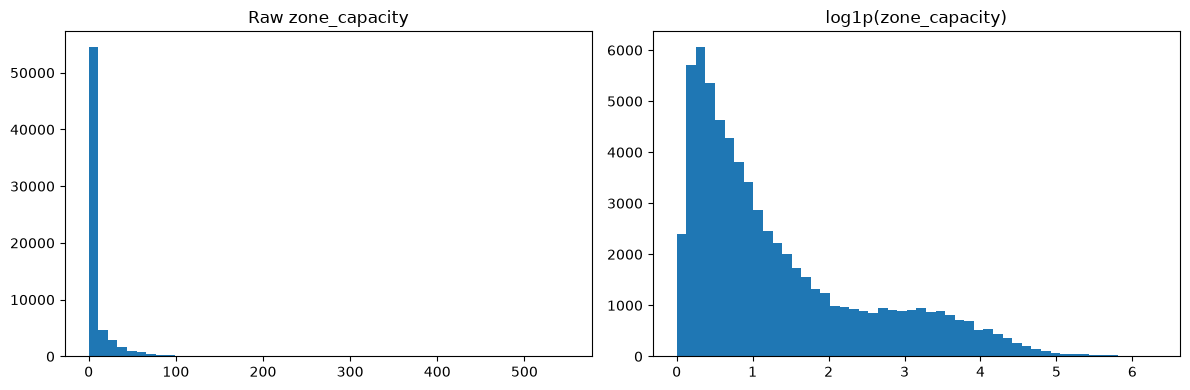

In [30]:
cap_pd = zone_capacity_df.select("zone_capacity").sample(0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cap_pd["zone_capacity"], bins=50)
axes[0].set_title("Raw zone_capacity")

axes[1].hist(np.log1p(cap_pd["zone_capacity"]), bins=50)
axes[1].set_title("log1p(zone_capacity)")
plt.tight_layout()
plt.show()

Use the trained Random Forest to generate predicted trip counts for the June test set, and join on zone capacity and weather for later allocation analysis.

In [31]:
allocation_df = (
    rf_tc.transform(test_df)
    .select(
        "PULocationID", "PU_Zone", "PU_Borough", "pickup_hour", "hour_of_day",
        "trip_count", F.col("prediction").alias("pred_trip_count")
    )
    .withColumn("pred_trip_count", F.greatest("pred_trip_count", F.lit(0.0)))  # clip negative preds
    .join(
        zone_capacity_df.select("PULocationID", "pickup_hour", "zone_capacity", "temperature_2m", "precipitation"),
        on=["PULocationID", "pickup_hour"], how="inner"
    )
)

allocation_df.cache()
print(f"Allocation rows (June test set): {allocation_df.count()}")
allocation_df.orderBy(F.desc("pred_trip_count")).select(
    "PU_Zone", "pickup_hour", "trip_count", "pred_trip_count", "zone_capacity"
).show(10)

Allocation rows (June test set): 122628
+--------------------+-------------------+----------+-----------------+------------------+
|             PU_Zone|        pickup_hour|trip_count|  pred_trip_count|     zone_capacity|
+--------------------+-------------------+----------+-----------------+------------------+
|Upper East Side S...|2025-06-19 18:00:00|       408|553.1507745699018|            71.895|
|      Midtown Center|2025-06-04 18:00:00|       584|544.4998399516129|172.48055555555553|
|      Midtown Center|2025-06-25 17:00:00|       579|544.4136257160203|196.76916666666665|
|      Midtown Center|2025-06-05 18:00:00|       635|543.0102340799459|178.23111111111112|
|      Midtown Center|2025-06-25 18:00:00|       581|542.7188751921226|175.08638888888888|
|      Midtown Center|2025-06-26 18:00:00|       552|541.6379502770247|180.15305555555557|
|      Midtown Center|2025-06-03 18:00:00|       668| 541.544011136736|169.53055555555554|
|Upper East Side S...|2025-06-26 18:00:00|       5

Remove zone-hours with very few actual trips, since the model's predictions are unreliable for these rare, low-volume cases.

In [ ]:
# Capacity floor: exclude zone-hours with too few trips to trust 
# pred_trip_count can be badly wrong for rare, extreme low-volume zone-hours

MIN_TRIP_COUNT = 20

allocation_df = allocation_df.filter(F.col("trip_count") >= MIN_TRIP_COUNT)
print(f"Allocation rows after capacity floor (trip_count >= {MIN_TRIP_COUNT}): {allocation_df.count()}")

Allocation rows after capacity floor (trip_count >= 20): 31926


Convert the allocation data to pandas, then define a function that greedily assigns taxis to zones in order of predicted demand, up to each zone's capacity.

In [33]:

alloc_pd = allocation_df.select(
    "PULocationID", "PU_Zone", "PU_Borough", "pickup_hour", "hour_of_day",
    "pred_trip_count", "zone_capacity", "temperature_2m", "precipitation", "trip_count"
).toPandas()

def greedy_allocate(df_hour, N):
    """Sort by predicted trip count, fill each zone up to its capacity until N is exhausted."""
    ranked = df_hour.sort_values("pred_trip_count", ascending=False).copy()
    cum_capacity_before = ranked["zone_capacity"].cumsum() - ranked["zone_capacity"]
    remaining_before = (N - cum_capacity_before).clip(lower=0)
    ranked["allocated_taxis"] = np.minimum(ranked["zone_capacity"], remaining_before)
    return ranked

example_hour = alloc_pd["pickup_hour"].iloc[0]
example = greedy_allocate(alloc_pd[alloc_pd["pickup_hour"] == example_hour], N=300)
example[["PU_Zone", "pred_trip_count", "zone_capacity", "allocated_taxis"]].head(15)

/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,PU_Zone,pred_trip_count,zone_capacity,allocated_taxis
4776,East Village,185.456784,71.134722,71.134722
6048,Lower East Side,104.665097,68.171389,68.171389
27677,West Village,86.925514,53.537222,53.537222
17338,Greenwich Village South,60.455283,37.496111,37.496111
1968,Little Italy/NoLiTa,47.033691,27.393611,27.393611
24314,Clinton East,46.025205,21.927222,21.927222
14742,Penn Station/Madison Sq West,44.871772,10.401111,10.401111
30886,Times Sq/Theatre District,44.564249,10.094167,9.938611
27233,Union Sq,38.448667,16.467778,0.000000
20518,East Chelsea,37.594889,18.416944,0.000000


Define a function to estimate trips captured by a given allocation, then a backtest comparing model-driven allocation against uniform allocation for a fixed fleet size N.

In [34]:
def captured_trip_count(df_hour, allocated_col):
    """Proxy: trips captured scale with the fraction of a zone's capacity actually serviced."""
    frac_served = np.minimum(df_hour[allocated_col] / df_hour["zone_capacity"].replace(0, np.nan), 1.0).fillna(0)
    return (frac_served * df_hour["trip_count"]).sum()

def run_backtest(alloc_pd, N):
    model_total, uniform_total = 0.0, 0.0
    for _, group in alloc_pd.groupby("pickup_hour"):
        model_alloc = greedy_allocate(group, N)
        model_total += captured_trip_count(model_alloc, "allocated_taxis")
        uniform = group.copy()
        uniform["allocated_taxis"] = N / len(group)
        uniform_total += captured_trip_count(uniform, "allocated_taxis")
    return model_total, uniform_total

N_TEST = 300
model_trips, uniform_trips = run_backtest(alloc_pd, N_TEST)
lift = (model_trips - uniform_trips) / uniform_trips
print(f"Model-driven captured trips: {model_trips:,.0f}")
print(f"Uniform captured trips:      {uniform_trips:,.0f}")
print(f"Lift: {lift:.2%}")

Model-driven captured trips: 650,272
Uniform captured trips:      752,055
Lift: -13.53%


Run the backtest across a range of fleet sizes and plot the resulting fleet-value curve for model-driven vs. uniform allocation.

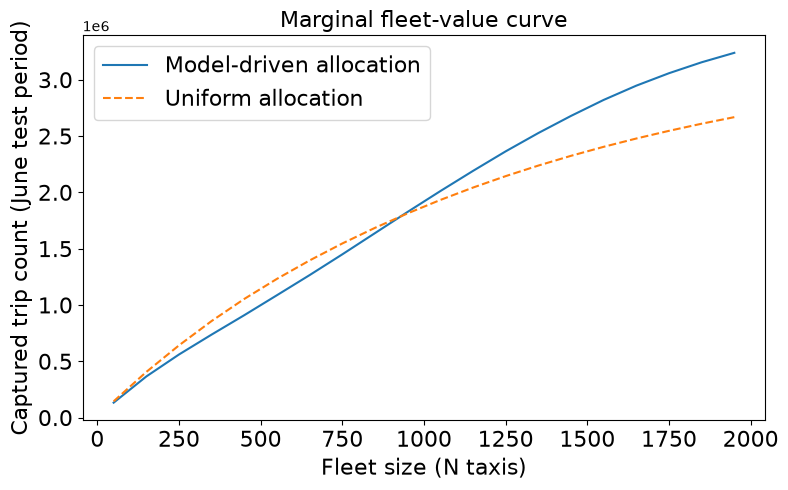

Model-driven allocation first exceeds uniform allocation at N = 950


,N,model_trip_count,uniform_trip_count,model_beats_uniform
0,50,1.325707e+05,1.445183e+05,False
1,150,3.651669e+05,4.054251e+05,False
2,250,5.603241e+05,6.413955e+05,False
3,350,7.373066e+05,8.577379e+05,False
4,450,9.095769e+05,1.053858e+06,False
5,550,1.086840e+06,1.232060e+06,False
6,650,1.265422e+06,1.395648e+06,False
7,750,1.449500e+06,1.546106e+06,False
8,850,1.637914e+06,1.684821e+06,False
9,950,1.826533e+06,1.813405e+06,True


In [70]:
LEGEND_FONTSIZE = 16
fleet_sizes = list(range(50, 2001, 100))
curve_results = [dict(N=N, **dict(zip(["model_trip_count", "uniform_trip_count"], run_backtest(alloc_pd, N))))
                  for N in fleet_sizes]
curve_df = pd.DataFrame(curve_results)

plt.figure(figsize=(8, 5))
plt.plot(curve_df["N"], curve_df["model_trip_count"], label="Model-driven allocation")
plt.plot(curve_df["N"], curve_df["uniform_trip_count"], linestyle="--", label="Uniform allocation")
plt.xlabel("Fleet size (N taxis)", fontsize=LEGEND_FONTSIZE)
plt.ylabel("Captured trip count (June test period)", fontsize=LEGEND_FONTSIZE)
plt.title("Marginal fleet-value curve", fontsize=LEGEND_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)
plt.xticks(fontsize=LEGEND_FONTSIZE)
plt.yticks(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.savefig("fleet_value_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Find the crossover fleet size for the Results/Recommendations TODOs ---
curve_df["model_beats_uniform"] = curve_df["model_trip_count"] > curve_df["uniform_trip_count"]
crossover_rows = curve_df[curve_df["model_beats_uniform"]]

if not crossover_rows.empty:
    crossover_N = crossover_rows["N"].iloc[0]
    print(f"Model-driven allocation first exceeds uniform allocation at N = {crossover_N}")
else:
    print("Model-driven allocation never exceeds uniform allocation in the tested range (50-2000).")

curve_df.head(15)

### use the full Random Forest model that projects number of trips (which is already filtered by zone & hour) and examine how changing a particular weather type shifts projections

For each zone, compute the average change in predicted trip count under each weather scenario, to measure weather sensitivity.

In [36]:
# Configuration: which model/data to sweep, and which weather variable/values to test 
TRIP_COUNT_MODEL = rf_tc            
TEST_DF          = test_df          
WEATHER_COL      = "precipitation"  
SCENARIO_VALUES  = [0.0, 0.2, 1.0, 3.1] 
SCENARIO_LABELS  = [str(v).replace(".", "_") for v in SCENARIO_VALUES]  # maps "3.1" to "3_1"
 
# Baseline: model's predicted trip count using each row's actual observed weather 
baseline_pred = (
    TRIP_COUNT_MODEL.transform(TEST_DF)
    .withColumnRenamed("prediction", "trip_count_baseline")
    .select("PULocationID", "pickup_hour", WEATHER_COL, "trip_count_baseline")
)

# Scenario sweep: for each precipitation value, force every row to that value and re-predict 
# (all other features, including zone and time, are left unchanged)
sweep_results = []
for val, label in zip(SCENARIO_VALUES, SCENARIO_LABELS):
    perturbed_df = TEST_DF.withColumn(WEATHER_COL, F.lit(val))  # overwrite precipitation with the scenario value
    trip_pred = TRIP_COUNT_MODEL.transform(perturbed_df).withColumnRenamed("prediction", f"trip_count_at_{label}")
    sweep_results.append(trip_pred.select("PULocationID", "pickup_hour", f"trip_count_at_{label}"))

# Join baseline and all scenario predictions together, keyed on zone + hour 
precip_scenario_predictions = baseline_pred
for res in sweep_results:
    precip_scenario_predictions = precip_scenario_predictions.join(res, on=["PULocationID", "pickup_hour"])

# For each scenario, compute how much the prediction changed relative to baseline
for val, label in zip(SCENARIO_VALUES, SCENARIO_LABELS):
    precip_scenario_predictions = precip_scenario_predictions.withColumn(
        f"change_in_trip_count_at_{label}",
        F.col(f"trip_count_at_{label}") - F.col("trip_count_baseline"),
    )

precip_scenario_predictions.cache().count()
precip_scenario_predictions.show(10)

+------------+-------------------+-------------+-------------------+------------------+------------------+------------------+------------------+---------------------------+---------------------------+---------------------------+---------------------------+
|PULocationID|        pickup_hour|precipitation|trip_count_baseline| trip_count_at_0_0| trip_count_at_0_2| trip_count_at_1_0| trip_count_at_3_1|change_in_trip_count_at_0_0|change_in_trip_count_at_0_2|change_in_trip_count_at_1_0|change_in_trip_count_at_3_1|
+------------+-------------------+-------------+-------------------+------------------+------------------+------------------+------------------+---------------------------+---------------------------+---------------------------+---------------------------+
|          39|2025-06-09 20:00:00|          0.3|  3.288252790516797| 3.288252790516797| 3.288252790516797| 3.288252790516797| 3.288252790516797|                        0.0|                        0.0|                        0.0| 

In [37]:
zone_sensitivity = (
    precip_scenario_predictions
    .groupBy("PULocationID")
    .agg(
        F.avg("change_in_trip_count_at_0_2").alias("avg_change_0_2"),
        F.avg("change_in_trip_count_at_1_0").alias("avg_change_1_0"),
        F.avg("change_in_trip_count_at_3_1").alias("avg_change_3_1"),
        F.count("*").alias("n_hours"),
    )
    .orderBy(F.desc("avg_change_3_1"))
)
zone_sensitivity.show(20)

+------------+--------------------+--------------------+--------------------+-------+
|PULocationID|      avg_change_0_2|      avg_change_1_0|      avg_change_3_1|n_hours|
+------------+--------------------+--------------------+--------------------+-------+
|         237|   1.597704798250947|  3.9089305868558473|   4.142788259839561|    719|
|         142|   2.024281524203604|   2.440382800725668|   2.472546269568521|    719|
|          79| 0.08958573960583315|-0.09303460252530357|  2.1709272640599715|    720|
|         132|  -0.465179664737822|   1.589074981736635|  2.0192202926244125|    720|
|         138|  0.2653843156430324|  0.7747856160166083|   2.008731635968047|    662|
|         230|  1.8791011966489855|  1.7729708211355166|  1.6147878475984392|    720|
|         161|  0.9890483017489916|   2.218627950815083|   1.068182935711235|    720|
|         236| 0.43481240889722084|  0.2568645389401635|  1.0489460395071903|    717|
|         255|  0.1637901202319266| 0.2299017902675812

For each zone, find the percentage of hours where all three weather scenario show zero change, to flag zones with no real weather sensitivity.

In [38]:
zero_change_zones = (
    precip_scenario_predictions
    .withColumn("all_zero", 
        (F.col("change_in_trip_count_at_0_2") == 0) & 
        (F.col("change_in_trip_count_at_1_0") == 0) & 
        (F.col("change_in_trip_count_at_3_1") == 0))
    .groupBy("PULocationID")
    .agg(F.avg(F.col("all_zero").cast("int")).alias("pct_zero_change"), F.count("*").alias("n"))
    .orderBy(F.desc("pct_zero_change"))
)
zero_change_zones.show(20)

+------------+------------------+---+
|PULocationID|   pct_zero_change|  n|
+------------+------------------+---+
|           2|               1.0|  4|
|          84|               1.0|  1|
|         199|               1.0|  1|
|          12|0.9850746268656716|402|
|         194|0.9774011299435028|177|
|          54|0.9709090909090909|275|
|          11|0.9628099173553719|242|
|         178|0.9624413145539906|213|
|         128|0.9622641509433962|106|
|          52|0.9599236641221374|524|
|          34|0.9587628865979382|291|
|         257|          0.953125|384|
|          40|0.9530075187969925|532|
|         153|0.9529411764705882|170|
|          35| 0.951937984496124|645|
|         188|0.9518950437317785|686|
|          26|0.9518072289156626|498|
|          67|0.9512893982808023|349|
|         195|0.9512195121951219|492|
|         228|0.9510268562401264|633|
+------------+------------------+---+
only showing top 20 rows


Build the final reliable zone-sensitivity table: exclude zones with 100% zero change, and keep only zones with at least 100 hours of data.

In [39]:

usable_zones = zero_change_zones.filter(F.col("pct_zero_change") < 1.0).select("PULocationID")

zone_sensitivity_final = (
    zone_sensitivity
    .join(usable_zones, on="PULocationID", how="inner")
    .filter(F.col("n_hours") >= 100)
)

zone_sensitivity_final.count()

227

Print how many zones out of the total show 100% zero weather sensitivity.

In [40]:
total_zones = precip_scenario_predictions.select("PULocationID").distinct().count()
zero_sensitivity_zones = zero_change_zones.filter(F.col("pct_zero_change") == 1.0).count()
print(f"Zones with 100% zero weather sensitivity: {zero_sensitivity_zones} / {total_zones}")

Zones with 100% zero weather sensitivity: 3 / 259


Attach zone names and boroughs to the final zone-sensitivity table and convert to pandas for plotting.

In [41]:
zone_lookup = zones.select(
    F.col("LocationID").alias("PULocationID"),
    F.col("Zone").alias("PU_Zone"),
    F.col("Borough").alias("PU_Borough"),
)

zone_sensitivity_named = (
    zone_sensitivity_final  
    .join(zone_lookup, on="PULocationID", how="left")
    .select("PULocationID", "PU_Zone", "PU_Borough", "avg_change_0_2", "avg_change_1_0", "avg_change_3_1", "n_hours")
)

zone_sensitivity_named_pd = zone_sensitivity_named.toPandas()

/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Build one clean, reliable set of zones (with names and boroughs) to reuse consistently in later steps.

In [42]:
reliable_zones = (
    zone_sensitivity_final
    .join(zone_lookup, on="PULocationID", how="left")
    .filter(F.col("PU_Borough") != "Unknown")  # excludes non-dispatchable placeholder entries only
)

Check the exclusion counts add up correctly: total zones, zero-sensitivity zones, thin-hours zones, and the overlap between them.

In [43]:
total_zones = precip_scenario_predictions.select("PULocationID").distinct().count()
zero_sensitivity_count = zero_change_zones.filter(F.col("pct_zero_change") == 1.0).count()
thin_hours_count = zone_sensitivity.filter(F.col("n_hours") < 100).count()
both_excluded = (
    zero_change_zones.filter(F.col("pct_zero_change") == 1.0)
    .join(zone_sensitivity.filter(F.col("n_hours") < 100), on="PULocationID", how="inner")
    .count()
)

print(f"Total zones: {total_zones}")
print(f"Zero-sensitivity zones: {zero_sensitivity_count}")
print(f"Thin-hours zones (<100): {thin_hours_count}")
print(f"Excluded by both: {both_excluded}")
print(f"Reliable (should match zone_sensitivity_final.count()): {zone_sensitivity_final.count()}")

Total zones: 259
Zero-sensitivity zones: 3
Thin-hours zones (<100): 32
Excluded by both: 3
Reliable (should match zone_sensitivity_final.count()): 227


### Baseline Zone Demand

Aggregate total trip count per zone across the full study period, and map it against zone geometry. This establishes which zones are structurally high-volume before comparing against the weather-sensitivity maps.

/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


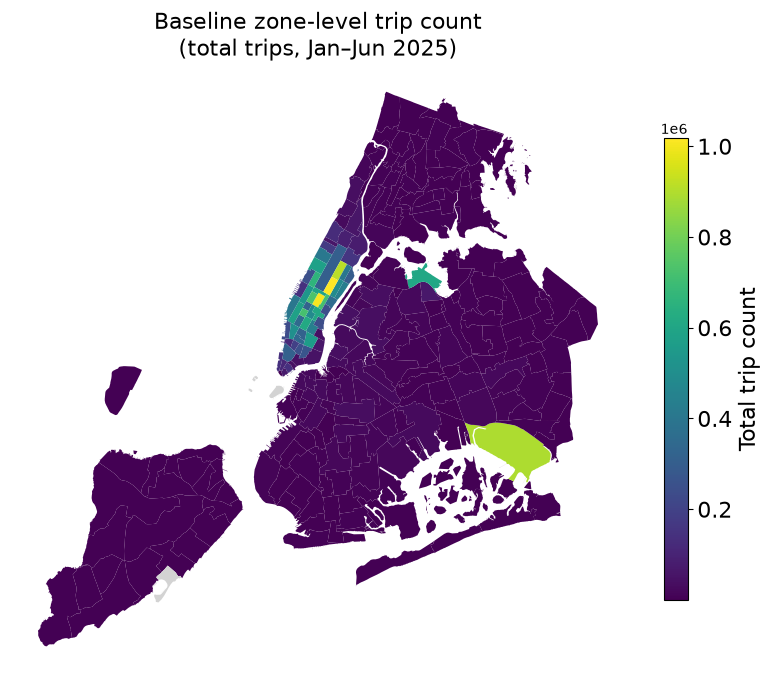

In [ ]:

zone_baseline = (
    zone_hour_agg
    .groupBy("PULocationID")
    .agg(F.sum("trip_count").alias("total_trip_count"))
    .toPandas()
)

zones_geo_baseline = zones_geo.merge(
    zone_baseline,
    left_on="LocationID", right_on="PULocationID", how="left"
)

fig, ax = plt.subplots(figsize=(8, 8))
zones_geo_baseline.plot(
    column="total_trip_count", cmap="viridis", legend=True, ax=ax,
    legend_kwds={"label": "Total trip count", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "No trips"}
)
ax.set_title("Baseline zone-level trip count\n(total trips, Jan–Jun 2025)", fontsize=LEGEND_FONTSIZE)

# Colorbar label + ticks
cbar = fig.axes[-1]
cbar.set_ylabel("Total trip count", fontsize=LEGEND_FONTSIZE)
cbar.tick_params(labelsize=LEGEND_FONTSIZE)

# "No trips" legend patch 
legend = ax.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(LEGEND_FONTSIZE)

ax.axis("off")
plt.tight_layout()
plt.savefig("zone_baseline_trip_count_map.png", dpi=200, bbox_inches="tight")
plt.show()

Merge the zone-sensitivity results onto the zone shapefile and plot a map of weather sensitivity by zone.

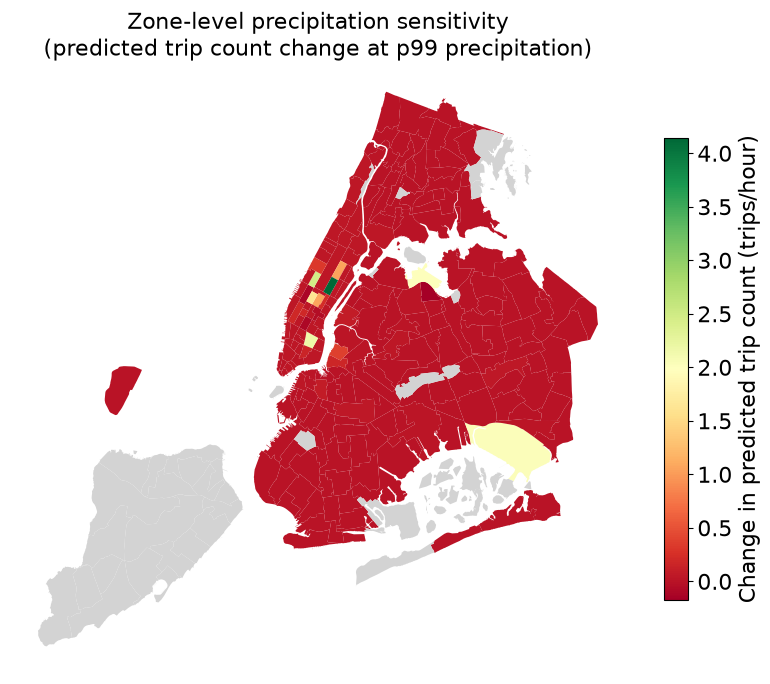

In [64]:
zones_geo_merged = zones_geo.merge(
    zone_sensitivity_named_pd,
    left_on="LocationID", right_on="PULocationID", how="left"
)

fig, ax = plt.subplots(figsize=(8, 8))
zones_geo_merged.plot(
    column="avg_change_3_1", cmap="RdYlGn", legend=True, ax=ax,
    legend_kwds={"label": "Change in predicted trip count (trips/hour)", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "Excluded / unreliable"},
)
cbar = fig.axes[-1]
cbar.set_ylabel("Change in predicted trip count (trips/hour)", fontsize=LEGEND_FONTSIZE)
cbar.tick_params(labelsize=LEGEND_FONTSIZE)
ax.set_title("Zone-level precipitation sensitivity\n(predicted trip count change at p99 precipitation)", fontsize=LEGEND_FONTSIZE)
ax.axis("off")
plt.tight_layout()
plt.savefig("zone_sensitivity_precipitation_map.png", dpi=200, bbox_inches="tight")
plt.show()

check how many unique zones remain in the final sensitivity table

In [46]:
zone_sensitivity_named_pd["PU_Zone"].nunique() 

227

Spot-check a specific JFK Airport hour to compare actual vs. predicted trip count.

In [47]:
allocation_df.filter((F.col("PU_Zone") == "JFK Airport") & (F.col("pickup_hour") == "2025-06-10 17:00:00")).select("trip_count", "pred_trip_count").show()

+----------+------------------+
|trip_count|   pred_trip_count|
+----------+------------------+
|       355|375.07950606367433|
+----------+------------------+



Show the top 5 zones ranked by weather sensitivity.

In [48]:
zone_sensitivity_named_pd.sort_values("avg_change_3_1", ascending=False).head(5)

,PULocationID,PU_Zone,PU_Borough,avg_change_0_2,avg_change_1_0,avg_change_3_1,n_hours
22,237,Upper East Side South,Manhattan,1.597705,3.908931,4.142788,719
61,142,Lincoln Square East,Manhattan,2.024282,2.440383,2.472546,719
81,79,East Village,Manhattan,0.089586,-0.093035,2.170927,720
171,132,JFK Airport,Queens,-0.465180,1.589075,2.019220,720
35,138,LaGuardia Airport,Queens,0.265384,0.774786,2.008732,662


In [49]:
# --- Pick realistic scenario values for temperature and snow from test data quantiles ---
temp_quantiles = test_df.approxQuantile("temperature_2m", [0.1, 0.5, 0.9, 0.99], 0.01)
snow_quantiles = test_df.approxQuantile("snowfall", [0.5, 0.9, 0.95, 0.99], 0.01)

print(f"Temperature quantiles (10/50/90/99%): {temp_quantiles}")
print(f"Snowfall quantiles (50/90/95/99%):     {snow_quantiles}")

Temperature quantiles (10/50/90/99%): [16.25, 22.3, 30.65, 40.2]
Snowfall quantiles (50/90/95/99%):     [0.0, 0.0, 0.0, 0.0]


### Extending Sensitivity Analysis: Temperature and Snowfall

The precipitation analysis above is repeated for two more weather variables: temperature and snowfall. Snowfall scenario values are chosen manually rather than from quantiles, since snow is a rare event and most quantiles are 0.0mm even across the full dataset — see note below.

In [50]:
def run_weather_sweep(model, test_df, weather_col, scenario_values):
    """Same logic as the precipitation sweep, generalized to any weather column."""
    labels = [str(round(v, 2)).replace(".", "_").replace("-", "neg") for v in scenario_values]

    baseline_pred = (
        model.transform(test_df)
        .withColumnRenamed("prediction", "trip_count_baseline")
        .select("PULocationID", "pickup_hour", weather_col, "trip_count_baseline")
    )

    sweep_results = []
    for val, label in zip(scenario_values, labels):
        perturbed_df = test_df.withColumn(weather_col, F.lit(val))
        trip_pred = model.transform(perturbed_df).withColumnRenamed("prediction", f"trip_count_at_{label}")
        sweep_results.append(trip_pred.select("PULocationID", "pickup_hour", f"trip_count_at_{label}"))

    result_df = baseline_pred
    for res in sweep_results:
        result_df = result_df.join(res, on=["PULocationID", "pickup_hour"])

    for val, label in zip(scenario_values, labels):
        result_df = result_df.withColumn(
            f"change_in_trip_count_at_{label}",
            F.col(f"trip_count_at_{label}") - F.col("trip_count_baseline"),
        )

    return result_df.cache()


def summarise_sensitivity(counterfactual_df, id_col="PULocationID"):
    """Same aggregation pattern as zone_sensitivity, generalized."""
    change_cols = [c for c in counterfactual_df.columns if c.startswith("change_in_trip_count_at_")]
    return (
        counterfactual_df
        .groupBy(id_col)
        .agg(
            *[F.avg(c).alias(c.replace("change_in_trip_count_at_", "avg_change_")) for c in change_cols],
            F.count("*").alias("n_hours"),
        )
    )

##### Temperature sensitivity

In [51]:
temp_quantiles = TEST_DF.approxQuantile("temperature_2m", [0.1, 0.5, 0.9, 0.99], 0.01)
print(f"Temperature quantiles (10/50/90/99%): {temp_quantiles}")

temp_counterfactual_df = run_weather_sweep(TRIP_COUNT_MODEL, TEST_DF, "temperature_2m", temp_quantiles)
temp_counterfactual_df.count()

temperature_sensitivity = summarise_sensitivity(temp_counterfactual_df).orderBy(F.desc("avg_change_40_2"))
temperature_sensitivity.show(20)

Temperature quantiles (10/50/90/99%): [16.25, 22.3, 30.65, 40.2]


+------------+--------------------+-------------------+-------------------+-------------------+-------+
|PULocationID|    avg_change_16_25|    avg_change_22_3|   avg_change_30_65|    avg_change_40_2|n_hours|
+------------+--------------------+-------------------+-------------------+-------------------+-------+
|         237| -7.6889660151897585|  2.151081218175433|  2.151081218175433|  2.151081218175433|    719|
|         132|  -7.245442988545743| 1.9218906317342108| 1.9218906317342108| 1.9218906317342108|    720|
|         161|  -5.021227631831909| 1.4778480508363152| 1.4778480508363152| 1.4778480508363152|    720|
|         236| -3.0889505630806897| 1.2596560050319414| 1.2596560050319414| 1.2596560050319414|    717|
|         138|  -5.873962758769143| 1.1960296632439666| 1.1960296632439666| 1.1960296632439666|    662|
|          79| -0.8195751389310871| 1.0631554405165438| 1.0631554405165438| 1.0631554405165438|    720|
|         142| -2.0267362371841684| 0.6504298545324957| 0.650429

##### Snowfall sensitivity

Snowfall quantiles are near-zero even across the full Jan–Jun dataset, so quantile-based scenarios aren't meaningful here. Manual values are used instead: 0.0 (no snow, the realistic case for June), 1.0 (light snow), 2.8 (the actual p99 across the full dataset), and 5.0 (a deliberate extrapolation beyond observed conditions, to check whether the model's response keeps scaling sensibly).


In [52]:
snow_scenario_values = [0.0, 1.0, 2.8, 5.0]

snow_counterfactual_df = run_weather_sweep(TRIP_COUNT_MODEL, TEST_DF, "snowfall", snow_scenario_values)
snow_counterfactual_df.count()

snow_sensitivity = summarise_sensitivity(snow_counterfactual_df).orderBy(F.desc("avg_change_5_0"))
snow_sensitivity.show(20)

+------------+--------------+--------------------+--------------------+--------------------+-------+
|PULocationID|avg_change_0_0|      avg_change_1_0|      avg_change_2_8|      avg_change_5_0|n_hours|
+------------+--------------+--------------------+--------------------+--------------------+-------+
|         230|           0.0|  2.6964267349357693|  2.6964267349357693|  2.6964267349357693|    720|
|          79|           0.0| 0.36665925098219415|  1.6162432100827933|  1.6162432100827933|    720|
|         145|           0.0| 0.30969503539287835|  0.4001795189203595|  0.4001795189203595|    713|
|         132|           0.0| 0.34577879500826886| 0.34577879500826886| 0.34577879500826886|    720|
|         249|           0.0| 0.24878280783447873| 0.24878280783447873| 0.24878280783447873|    720|
|         255|           0.0|-9.34805458317275...|  0.0780509152151191|  0.0780509152151191|    676|
|         234|           0.0|0.026813712734278315|0.026813712734278315|0.026813712734278315

In [53]:
def build_final_zone_sensitivity(counterfactual_df, sensitivity_df, id_col="PULocationID", n_hours_floor=100):
    """
    Mirrors the precipitation zero_change_zones -> zone_sensitivity_final pattern (cells 79-82),
    generalized to any set of change_in_trip_count_at_* columns.
    n_hours_floor=100 to match cell 82's actual filter (NOTE: cell 86's comment claims 400 - verify which you want).
    """
    change_cols = [c for c in counterfactual_df.columns if c.startswith("change_in_trip_count_at_")]

    all_zero_cond = F.col(change_cols[0]) == 0
    for c in change_cols[1:]:
        all_zero_cond = all_zero_cond & (F.col(c) == 0)

    zero_change_zones = (
        counterfactual_df
        .withColumn("all_zero", all_zero_cond)
        .groupBy(id_col)
        .agg(F.avg(F.col("all_zero").cast("int")).alias("pct_zero_change"), F.count("*").alias("n"))
    )

    usable_zones = zero_change_zones.filter(F.col("pct_zero_change") < 1.0).select(id_col)

    return (
        sensitivity_df
        .join(usable_zones, on=id_col, how="inner")
        .filter(F.col("n_hours") >= n_hours_floor)
    )


temperature_sensitivity_final = build_final_zone_sensitivity(temp_counterfactual_df, temperature_sensitivity)
snow_sensitivity_final = build_final_zone_sensitivity(snow_counterfactual_df, snow_sensitivity)

print(f"Temperature: {temperature_sensitivity_final.count()} reliable zones")
print(f"Snowfall: {snow_sensitivity_final.count()} reliable zones")

Temperature: 227 reliable zones
Snowfall: 88 reliable zones


In [54]:
def to_named_pandas(sensitivity_final_df, zone_lookup):
    avg_change_cols = [c for c in sensitivity_final_df.columns if c.startswith("avg_change_")]
    named = (
        sensitivity_final_df
        .join(zone_lookup, on="PULocationID", how="left")
        .select("PULocationID", "PU_Zone", "PU_Borough", *avg_change_cols, "n_hours")
    )
    pd_df = named.toPandas()
    pd_df["max_abs_sensitivity"] = pd_df[avg_change_cols].abs().max(axis=1)
    return pd_df


temperature_sensitivity_named_pd = to_named_pandas(temperature_sensitivity_final, zone_lookup)
snow_sensitivity_named_pd = to_named_pandas(snow_sensitivity_final, zone_lookup)

/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/harryellis/Documents/GitHub/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


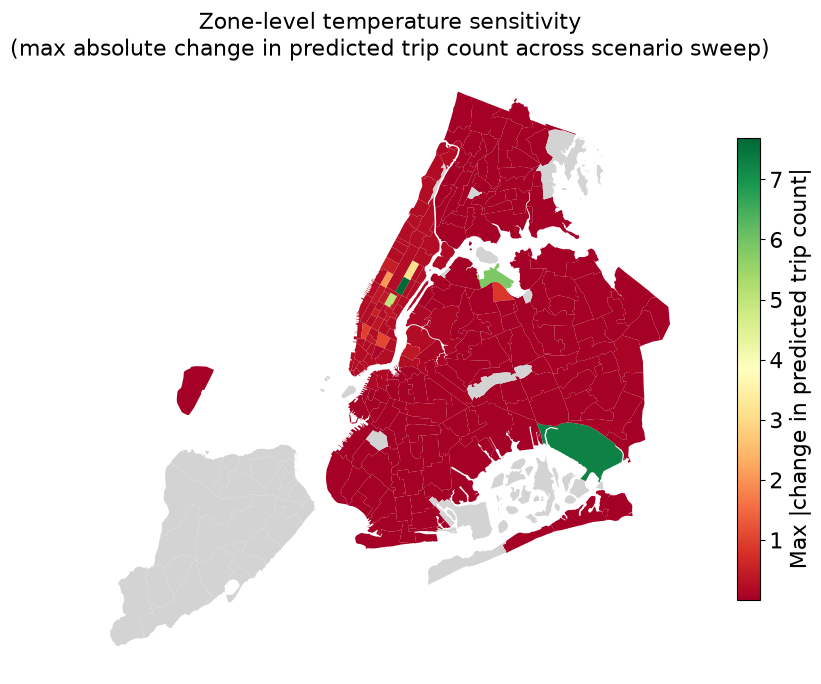

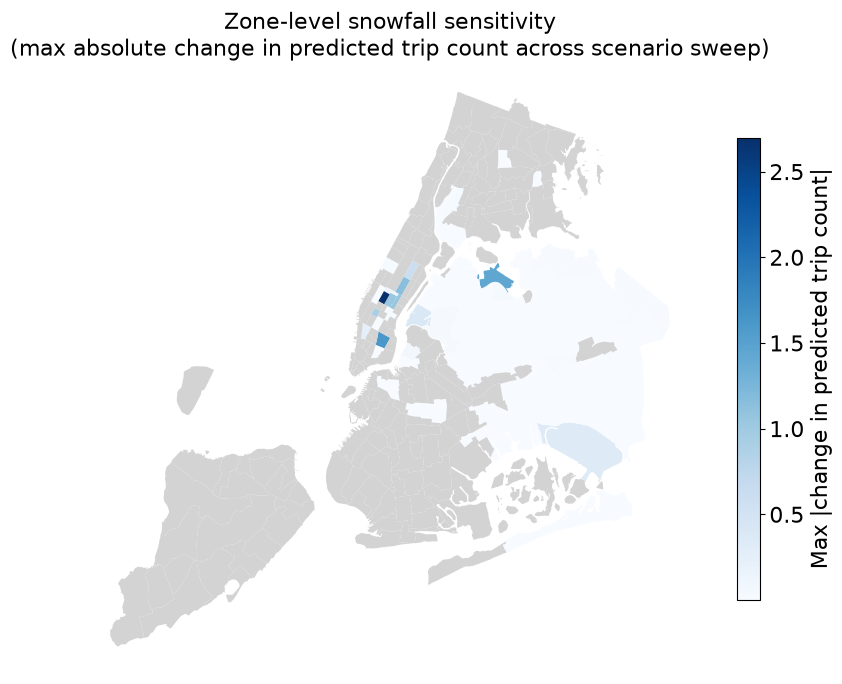

In [67]:
def plot_sensitivity_map(sensitivity_pd, title, filename, cmap="RdYlGn"):
    merged = zones_geo.merge(sensitivity_pd, left_on="LocationID", right_on="PULocationID", how="left")
    fig, ax = plt.subplots(figsize=(8, 8))
    merged.plot(
        column="max_abs_sensitivity", cmap=cmap, legend=True, ax=ax,
        legend_kwds={"label": "Max |change in predicted trip count|", "shrink": 0.6},
        missing_kwds={"color": "lightgrey", "label": "Excluded / unreliable"}
    )
    ax.set_title(title, fontsize=LEGEND_FONTSIZE)

    # Colorbar label + ticks
    cbar = fig.axes[-1]
    cbar.set_ylabel("Max |change in predicted trip count|", fontsize=LEGEND_FONTSIZE)
    cbar.tick_params(labelsize=LEGEND_FONTSIZE)

    # "Excluded / unreliable" legend patch — separate legend object
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_FONTSIZE)

    ax.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()


plot_sensitivity_map(
    temperature_sensitivity_named_pd,
    "Zone-level temperature sensitivity\n(max absolute change in predicted trip count across scenario sweep)",
    "zone_temperature_sensitivity_map.png",
)

plot_sensitivity_map(
    snow_sensitivity_named_pd,
    "Zone-level snowfall sensitivity\n(max absolute change in predicted trip count across scenario sweep)",
    "zone_snowfall_sensitivity_map.png",
    cmap="Blues",
)